<a href="https://colab.research.google.com/github/THARIK-ASAN2003/THARIK-ASAN2003/blob/main/CAT_BOOST_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.6 MB/s eta 0:00:00


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import RobustScaler, LabelEncoder
from catboost import CatBoostClassifier, Pool
import warnings
import json
warnings.filterwarnings('ignore')

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

In [4]:
# Load the data
train = pd.read_csv('/content/Railofy_training_data_for_model.csv')
test = pd.read_csv("/content/Railofy_testing_data_for_model.csv")

In [5]:
# Null value check function
def check_null_values(df, dataset_name):
    print(f"\nNull Value Check for {dataset_name}:")
    null_counts = df.isna().sum()
    null_percentages = (df.isna().sum() / len(df)) * 100
    null_info = pd.DataFrame({
        'Null Count': null_counts,
        'Null Percentage': null_percentages
    })
    null_info = null_info[null_info['Null Count'] > 0]
    if len(null_info) > 0:
        print(null_info)
    else:
        print("No null values found!")
    return null_info

In [6]:
# Handle null values function
def handle_null_values(df):
    df_clean = df.copy()
    numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
    for col in numeric_columns:
        if df[col].isna().sum() > 0:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    categorical_columns = df.select_dtypes(include=['object']).columns
    for col in categorical_columns:
        if df[col].isna().sum() > 0:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    return df_clean

In [7]:
# Check and handle null values
train_nulls = check_null_values(train, "Training Data")
test_nulls = check_null_values(test, "Test Data")

if len(train_nulls) > 0:
    train_clean = handle_null_values(train)
else:
    train_clean = train

if len(test_nulls) > 0:
    test_clean = handle_null_values(test)
else:
    test_clean = test



Null Value Check for Training Data:
No null values found!

Null Value Check for Test Data:
No null values found!


In [8]:
# Verify null values handled
print("\nVerifying null values after handling:")
check_null_values(train_clean, "Cleaned Training Data")
check_null_values(test_clean, "Cleaned Test Data")


Verifying null values after handling:

Null Value Check for Cleaned Training Data:
No null values found!

Null Value Check for Cleaned Test Data:
No null values found!


,Null Count,Null Percentage


In [9]:
# Data preprocessing function
def preprocess_data(train_df, test_df, target_column='target'):
    if target_column in train_df.columns:
        y = train_df[target_column].copy()
        X = train_df.drop(columns=[target_column])
    else:
        y = None
        X = train_df.copy()

    X_test = test_df.copy()
    numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns
    categorical_columns = X.select_dtypes(include=['object']).columns
    rb_scaler = RobustScaler()
    label_encoders = {}

    if len(numeric_columns) > 0:
        X_numeric = pd.DataFrame(rb_scaler.fit_transform(X[numeric_columns]),
                                columns=numeric_columns,
                                index=X.index)
        X_test_numeric = pd.DataFrame(rb_scaler.transform(X_test[numeric_columns]),
                                     columns=numeric_columns,
                                     index=X_test.index)
    else:
        X_numeric = pd.DataFrame(index=X.index)
        X_test_numeric = pd.DataFrame(index=X_test.index)

    X_categorical = pd.DataFrame(index=X.index)
    X_test_categorical = pd.DataFrame(index=X_test.index)

    for col in categorical_columns:
        le = LabelEncoder()
        X_categorical[col] = le.fit_transform(X[col])
        X_test_categorical[col] = le.transform(X_test[col])
        label_encoders[col] = le

    X_processed = pd.concat([X_numeric, X_categorical], axis=1)
    X_test_processed = pd.concat([X_test_numeric, X_test_categorical], axis=1)

    return X_processed, X_test_processed, y, label_encoders, list(categorical_columns)

In [10]:
# Apply preprocessing
X_processed, X_test_processed, y, label_encoders, cat_features = preprocess_data(train_clean, test_clean)


In [11]:
# Split the data
X_train, X_valid, y_train, y_valid = train_test_split(
    X_processed, y,
    test_size=0.2,
    random_state=2021
)

print("Dataset shapes after preprocessing:")
print(f"X_train: {X_train.shape}")
print(f"X_valid: {X_valid.shape}")
print(f"X_test: {X_test_processed.shape}")

Dataset shapes after preprocessing:
X_train: (29420, 24)
X_valid: (7355, 24)
X_test: (3847, 24)


In [12]:
# Train CatBoost model
catboost_model = CatBoostClassifier(
    iterations=10000,
    learning_rate=0.01,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=2022,
    verbose=100
)

In [13]:
# Prepare data for CatBoost
train_pool = Pool(X_train, y_train, cat_features=cat_features)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features)

In [14]:
# Train the model
catboost_model.fit(
    train_pool,
    eval_set=valid_pool,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.7675089	best: 0.7675089 (0)	total: 132ms	remaining: 21m 56s
100:	test: 0.8219422	best: 0.8219422 (100)	total: 5.66s	remaining: 9m 14s
200:	test: 0.8395618	best: 0.8395618 (200)	total: 10.6s	remaining: 8m 34s
300:	test: 0.8506649	best: 0.8506649 (300)	total: 15.3s	remaining: 8m 12s
400:	test: 0.8592556	best: 0.8592556 (400)	total: 21s	remaining: 8m 22s
500:	test: 0.8665258	best: 0.8665258 (500)	total: 25.2s	remaining: 7m 57s
600:	test: 0.8718576	best: 0.8718576 (600)	total: 32.2s	remaining: 8m 23s
700:	test: 0.8766100	best: 0.8766100 (700)	total: 36.9s	remaining: 8m 9s
800:	test: 0.8805519	best: 0.8805519 (800)	total: 43.6s	remaining: 8m 20s
900:	test: 0.8843230	best: 0.8843230 (900)	total: 51.7s	remaining: 8m 42s
1000:	test: 0.8878656	best: 0.8878656 (1000)	total: 55.5s	remaining: 8m 18s
1100:	test: 0.8914717	best: 0.8914717 (1100)	total: 1m 2s	remaining: 8m 23s
1200:	test: 0.8948545	best: 0.8948545 (1200)	total: 1m 8s	remaining: 8m 20s
1300:	test: 0.8982270	best: 0.8982270 

In [15]:
# Make predictions
val_pred = catboost_model.predict(X_valid)
val_pred_proba = catboost_model.predict_proba(X_valid)[:, 1]
test_pred_proba = catboost_model.predict_proba(X_test_processed)

In [16]:
# Create submission file
submission_file = pd.DataFrame()
submission_file['pk'] = test['pk']
submission_file['target'] = test_pred_proba[:, 1]
submission_file.to_csv('submission.csv', index=False)

print("\nSubmission file created successfully!")
print("\nSubmission Preview:")
print(submission_file.head())

In [18]:
# Model Evaluation and Visualization
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [19]:
# Create evaluation plots
plt.figure(figsize=(20, 15))

<Figure size 2000x1500 with 0 Axes>

<Figure size 2000x1500 with 0 Axes>

Text(0.5, 262.22222222222223, 'Predicted Label')

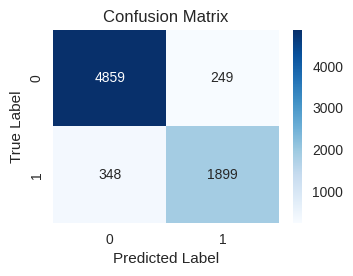

In [20]:
# Confusion Matrix
plt.subplot(2, 2, 1)
cm = confusion_matrix(y_valid, val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

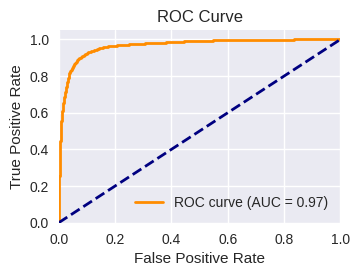

In [21]:
# ROC Curve
plt.subplot(2, 2, 2)
fpr, tpr, _ = roc_curve(y_valid, val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

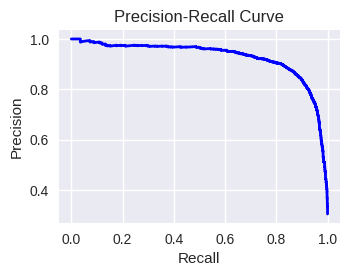

In [22]:
# Precision-Recall Curve
plt.subplot(2, 2, 3)
precision, recall, _ = precision_recall_curve(y_valid, val_pred_proba)
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)

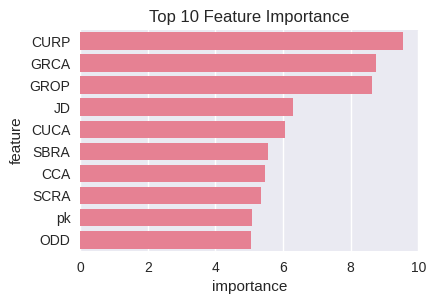

In [23]:
# Feature Importance
plt.subplot(2, 2, 4)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': catboost_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 Feature Importance')

plt.tight_layout()
plt.show()

In [24]:
# Print model performance metrics
print("\nModel Performance Metrics:")
print("\nClassification Report:")
print(classification_report(y_valid, val_pred))
print(f"\nAccuracy Score: {accuracy_score(y_valid, val_pred):.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"Precision Score: {np.average(precision):.4f}")
print(f"Recall Score: {np.average(recall):.4f}")
print(f"F1 Score: {2 * (np.average(precision) * np.average(recall)) / (np.average(precision) + np.average(recall)):.4f}")



Model Performance Metrics:

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      5108
           1       0.88      0.85      0.86      2247

    accuracy                           0.92      7355
   macro avg       0.91      0.90      0.90      7355
weighted avg       0.92      0.92      0.92      7355


Accuracy Score: 0.9188
ROC AUC Score: 0.9659
Precision Score: 0.6428
Recall Score: 0.8235
F1 Score: 0.7220


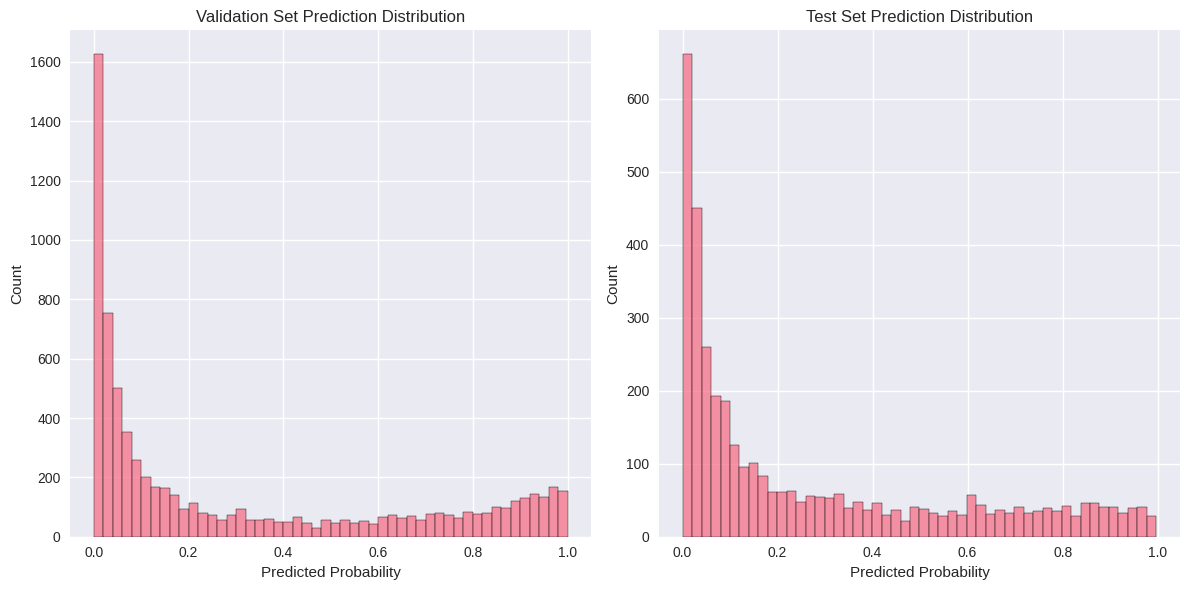

In [25]:
# Prediction Distribution Analysis
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(val_pred_proba, bins=50)
plt.title('Validation Set Prediction Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(test_pred_proba[:, 1], bins=50)
plt.title('Test Set Prediction Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [26]:
# Save analysis results
analysis_results = {
    'model_accuracy': accuracy_score(y_valid, val_pred),
    'roc_auc': roc_auc,
    'feature_importance': feature_importance.head(10).to_dict(),
    'confusion_matrix': cm.tolist()
}

with open('model_analysis_results.json', 'w') as f:
    json.dump(analysis_results, f)

print("\nAnalysis completed and results saved!")
print(f"Final Model Accuracy: {analysis_results['model_accuracy']:.4f}")
print(f"ROC AUC Score: {analysis_results['roc_auc']:.4f}")


Analysis completed and results saved!
Final Model Accuracy: 0.9188
ROC AUC Score: 0.9659
